# Regression

## Imports

In [1]:
import time
import math
import copy

from IPython.display import display
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.constrained_layout.use"] = True

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV

from regression.base.basemodel import BaseModel
from regression.base.basegdmodel import BaseGDModel
from regression.dataset import CaliforniaHousingDataset as Dataset
from regression.pipeline import get_pipeline
from regression.eda.eda import EDA

# Linear regression
from regression.linear_regression.diagnostics import GaussMarkovDiagnostics
from regression.linear_regression.ols import OLS
from regression.linear_regression.wls import WLS
from regression.linear_regression.mbgd import MBGD

# Regularization and features selection
from regression.regularization.ridge_regression import RidgeRegression, RidgeRegressionCV
from regression.regularization.lasso_regression import LassoRegression, LassoRegressionCV
from regression.regularization.elastic_net import ElasticNet, ElasticNetCV
from regression.features_selection.features_selection import \
    forward_selection, backward_elimination, lasso_selection

# Nonlinear basis
from regression.nonlinear_basis.polynomial import PolynomialBasis
from regression.nonlinear_basis.fourier import FourierBasis
from regression.nonlinear_basis.rbf import RBF
from regression.nonlinear_basis.validation_curve import ValidationExperiment
from regression.nonlinear_basis.ablation_study import AblationStudy

# Advanced
from regression.advanced.gpr import GPR
from regression.advanced.irls import IRLS
from regression.advanced.kernel_ridge import KernelRidgeCV
from regression.advanced.bias_variance import BiasVarianceAnalyzer
from regression.advanced.bayes_reg import BayesianLinearRegression

# Evaluation
from regression.evaluation.visualizer import Visualizer
from regression.evaluation.evaluator import Evaluator

# Sensitivity & Robustness
from regression.sensitivity_robustness import (
    sensitivity_split_analysis,
    plot_split_boxplots,
    noise_injection_analysis,
    feature_corruption_analysis,
    plot_loss_curves
)

# Benchmark
from regression.benchmark import benchmark_models

## Dataset

In [2]:
d = Dataset()
d.split()

In [ ]:
eda = EDA(d)

### Missing values

In [ ]:
display(eda.missing_values())

### Descriptive statistics

In [ ]:
display(eda.descriptive_stats())

### Target distribution

In [ ]:
eda.plot_target_distribution()
plt.show()

### Scatter

In [ ]:
eda.plot_scatter_features_target()
plt.show()

### Correlation matrix

In [ ]:
eda.plot_corrrelation_matrix()
plt.show()

### Outliers

In [ ]:
eda.plot_outliers()
plt.show()

## Models

### Linear regression

#### Gauss-Markov assumption

In [ ]:
model = get_pipeline(OLS())
model.fit(d.X_train, d.y_train)
y_pred_train = model.predict(d.X_train)
diag = GaussMarkovDiagnostics()

##### Residuals plot

In [ ]:
residuals_train = d.y_train - y_pred_train
diag.plot_residuals(d.y_train, y_pred_train)

plt.show()

##### QQ-plot

In [ ]:
diag.plot_qq(residuals_train)
plt.show()

##### Breusch–Pagan test

In [ ]:
result = diag.breusch_pagan_test(d.X_train, residuals_train)
display(result)

### Regularization and features selecton

#### Ridge Regression

In [ ]:
lambdas = np.logspace(-10, 1, 12)

In [ ]:
model = get_pipeline(RidgeRegressionCV(alphas=lambdas, cv=10))
model.fit(d.X_train, d.y_train)

In [ ]:
print(model.named_steps["predictor"].best_alpha_)

In [ ]:
model.named_steps["predictor"].plot_regularization_path(title="Rigde Regularization Path")

#### Lasso Regression

In [ ]:
lambdas = np.logspace(-10, 1, 12)

In [ ]:
model = get_pipeline(LassoRegressionCV(alphas=lambdas, cv=10))
model.fit(d.X_train, d.y_train)

In [ ]:
print(model.named_steps["predictor"].best_alpha_)

In [ ]:
model.named_steps["predictor"].plot_regularization_path(title="Rigde Regularization Path")

#### Elastic Net

In [ ]:
lambda_1s = np.logspace(-10, 1, 12)
lambda_2s = np.logspace(-10, 1, 12)

In [ ]:
model = get_pipeline(ElasticNetCV(alpha_1s=lambda_1s, alpha_2s=lambda_2s, cv=10))
model.fit(d.X_train, d.y_train)

In [ ]:
model.named_steps["predictor"].plot_optimal_region(title="Elastic Net Optimal Region")

#### Features Selection

In [ ]:
k_features = 5

In [ ]:
model = get_pipeline(LassoRegression())

##### Forward

In [ ]:
forward_selection(d.X_train, d.y_train, model, k_features, d.feature_names)

##### Backward

In [ ]:
backward_elimination(d.X_train, d.y_train, model, k_features, d.feature_names)

##### Lasso

In [ ]:
lambdas = np.logspace(-10, 1, 12)

In [ ]:
lasso_selection(d.X_train, d.y_train, d.feature_names, alphas=lambdas, cv=10)

### Non-linear basis and Ablation study

#### Validation Curve

In [ ]:
exp = ValidationExperiment()
exp.load_data()
exp.run_all()

Ablation Study


===== VALIDATION ABLATION RESULTS =====
RBF                  : 0.637879
Fourier              : 0.419886
Polynomial           : 65.135821
NO_RBF               : 0.493888
NO_FOURIER           : 1767.324896
NO_POLY              : 0.417499
NO_ECONOMIC          : 255.325352
NO_DENSITY           : 0.442693
NO_SPATIAL           : 605.146135
NO_MedInc            : 807.261046
NO_HouseAge          : 8.008103
NO_AveRooms          : 189.150772
NO_AveBedrms         : 90.545996
NO_Population        : 60.263111
NO_AveOccup          : 0.471775
NO_Latitude          : 187.599768
NO_Longitude         : 161.883225
FULL                 : 78.553132


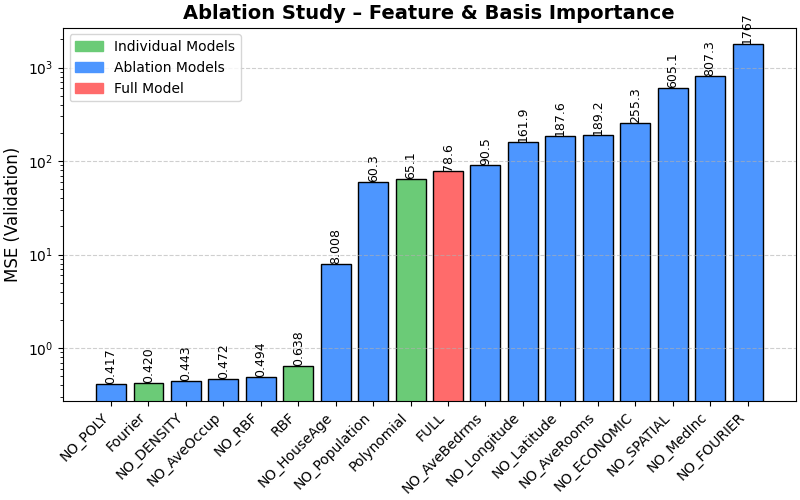

In [2]:
exp = AblationStudy()
exp.run_all()
exp.print_results()
exp.plot()

In [ ]:
exp.rank_features() 
exp.plot_importance()

#### Interaction

In [ ]:
X_train, y_train = d.X_train, d.y_train
X_val, y_val = d.X_val, d.y_val

y_train = y_train.ravel()
y_val = y_val.ravel()

# ===== MODEL WITH INTERACTION =====
model_inter = get_pipeline(
    predictor=LinearRegression(),
    features=None,
    use_interaction=True
)

model_inter.fit(X_train, y_train)
y_pred_inter = model_inter.predict(X_val)

mse_inter = mean_squared_error(y_val, y_pred_inter)
print("MSE (with interaction):", mse_inter)


In [ ]:
model_base = get_pipeline(
    predictor=LinearRegression(),
    features=PolynomialBasis(degree=2),
    use_interaction=False
)

model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_val)

mse_base = mean_squared_error(y_val, y_pred_base)
print("MSE (no interaction):", mse_base)

print("Improvement:", mse_base - mse_inter)

## Advanced

### Bayesian Regression


In [ ]:
# ===== MODEL =====
X_train, y_train = d.X_train, d.y_train
X_test, y_test = d.X_test, d.y_test
model = BayesianLinearRegression(alpha=1.0, beta=10.0)
model.fit(X_train, y_train)


In [ ]:
 # ===== POSTERIOR =====
m_N, S_N = model.get_posterior()
print("Posterior mean shape:", m_N.shape)
print("Posterior covariance shape:", S_N.shape)

In [ ]:
 # ===== PREDICT =====
y_mean, y_std = model.predict_dist(X_test)
mse = np.mean((y_test - y_mean) ** 2)
print(f"MSE = {mse:.6f}")

In [ ]:
# ===== PLOT (1D visualization) =====
X_plot = X_test[:, 0]
idx = np.argsort(X_plot)

plt.figure(figsize=(8, 5))

# data test
plt.scatter(X_plot, y_test, s=10, label="Test data")

# mean prediction
plt.plot(X_plot[idx], y_mean[idx], label="Mean")

# vùng bất định ±2σ
plt.fill_between(
    X_plot[idx],
    y_mean[idx] - 2*y_std[idx],
    y_mean[idx] + 2*y_std[idx],
    alpha=0.3,
    label="±2σ"
)
plt.xlabel("Median Income (MedInc) - Feature 0")
plt.ylabel("House Price (Target)")
plt.legend()
plt.title("Bayesian Linear Regression (Uncertainty)")
plt.show()


In [ ]:
#Optimazation alpha , beta using Evidence Maximization to compare with CV 
start = time.time()

model_em = BayesianLinearRegression()
model_em.evidence_maximization(X_train, y_train)

y_pred_em = model_em.predict(X_test)

em_time = time.time() - start
em_mse = mean_squared_error(y_test, y_pred_em)

#  CV 
param_grid = {
    "alpha": [0.1, 1, 10],
    "beta": [1, 10, 100]
}

start = time.time()

grid = GridSearchCV(
    BayesianLinearRegression(),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)

y_pred_cv = grid.predict(X_test)

cv_time = time.time() - start
cv_mse = mean_squared_error(y_test, y_pred_cv)

# ================= RESULT =================
print("\n===== EVIDENCE MAXIMIZATION =====")
print("alpha:", model_em.alpha)
print("beta:", model_em.beta)
print("MSE:", em_mse)
print("Time:", em_time)

print("\n===== CROSS VALIDATION =====")
print("Best params:", grid.best_params_)
print("MSE:", cv_mse)
print("Time:", cv_time)

print("\n===== COMPARISON =====")
print(f"EM faster than CV? {em_time < cv_time}")
print(f"EM better MSE than CV? {em_mse < cv_mse}")

#### Kernel Ridge Regression

In [ ]:
models = {
    "Ridge": get_pipeline(RidgeRegression()),
    "RBF Ridge": get_pipeline(KernelRidgeCV(kernel='rbf', cv=2)),
    "Polynomial Ridge": get_pipeline(KernelRidgeCV(kernel='polynomial', cv=2))
}
evaluator = Evaluator()

result = evaluator.compare_models_cv(models, d.X_train, d.y_train)

print(result)

result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
print(result)

stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train
)

print(stat_result)

### Gaussian Process Regression

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(len(d.X_train), 2000, replace=False)
X_sub = d.X_train[idx]
y_sub = d.y_train[idx]

model = get_pipeline(GPR())
model.fit(X_sub, y_sub)

y_pred, y_std = model.predict(d.X_train)
y_true = d.y_train
print("min std:", y_std.min())
print("max std:", y_std.max())

In [ ]:
feature_names = getattr(d, "feature_names", [f"Feature {i}" for i in range(d.X.shape[1])])

n_features = d.X.shape[1]

for i in range(n_features):
    x_plot = d.X_train[:, i]
    idx = np.argsort(x_plot)

    plt.subplot(3, 3, i+1)

    # Prediction mean
    plt.plot(x_plot[idx], y_pred[idx], label="Pred", linewidth=1)

    # Uncertainty band
    plt.fill_between(
        x_plot[idx],
        y_pred[idx] - 1.96 * y_std[idx],
        y_pred[idx] + 1.96 * y_std[idx],
        alpha=0.5
    )

    # True points
    plt.scatter(x_plot, y_true, s=5, alpha=0.3)

    plt.title(feature_names[i])
    plt.xlabel("Feature value")
    plt.ylabel("Price")
plt.gcf().suptitle("Posterior predictive with error bars")
plt.show()

### Robust Regression

In [ ]:
huber = get_pipeline(IRLS(loss="huber"))
huber.fit(d.X_train, d.y_train)
y_pred_huber = huber.predict(d.X_test)

student = get_pipeline(IRLS(loss="student-t"))
student.fit(d.X_train, d.y_train)
y_pred_student = student.predict(d.X_test)

model_ols = get_pipeline(OLS())
model_ols.fit(d.X_train, d.y_train)
y_pred_ols = model_ols.predict(d.X_test)

y_true = d.y_test

print("=== Overall MSE ===")
print(f"OLS: {mean_squared_error(y_true, y_pred_ols):.4f}")
print(f"Huber IRLS: {mean_squared_error(y_true, y_pred_huber):.4f}")
print(f"Student-t IRLS: {mean_squared_error(y_true, y_pred_student):.4f}")

In [ ]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2


def outlier_sensitivity_df(models, data, outlier_ratio=0.1, noise_scale=5.0):
    rows = []

    # ===== CLEAN TRAIN =====
    clean_scores = {}

    for name, model in models.items():
        model.fit(data.X_train, data.y_train)
        y_pred = model.predict(data.X_test)

        mse, rmse, mae, r2 = compute_metrics(data.y_test, y_pred)
        clean_scores[name] = (mse, rmse, mae, r2)

    # ===== ADD OUTLIERS =====
    y_train_noisy = data.y_train.copy()

    idx = np.random.choice(
        len(y_train_noisy),
        int(outlier_ratio * len(y_train_noisy)),
        replace=False
    )

    y_train_noisy[idx] += noise_scale * np.std(y_train_noisy)

    # ===== NOISY TRAIN =====
    noisy_scores = {}

    for name, model in models.items():
        model.fit(data.X_train, y_train_noisy)
        y_pred = model.predict(data.X_test)

        mse, rmse, mae, r2 = compute_metrics(data.y_test, y_pred)
        noisy_scores[name] = (mse, rmse, mae, r2)

    # ===== BUILD DATAFRAME =====
    for name in models.keys():
        cmse, crmse, cmae, cr2 = clean_scores[name]
        nmse, nrmse, nmae, nr2 = noisy_scores[name]

        rows.append({
            "Model": name,

            "MSE_clean": cmse,
            "MSE_noisy": nmse,
            "MSE_sensitivity": (nmse - cmse) / (cmse + 1e-8),

            "RMSE_clean": crmse,
            "RMSE_noisy": nrmse,
            "RMSE_sensitivity": (nrmse - crmse) / (crmse + 1e-8),

            "MAE_clean": cmae,
            "MAE_noisy": nmae,
            "MAE_sensitivity": (nmae - cmae) / (cmae + 1e-8),

            "R2_clean": cr2,
            "R2_noisy": nr2,
            "R2_sensitivity": (cr2 - nr2),
        })

    return pd.DataFrame(rows)

models = {
    "OLS": get_pipeline(OLS()),
    "IRLS (Huber)": get_pipeline(IRLS(loss="huber")),
    "IRLS (Student-t)": get_pipeline(IRLS(loss="student-t")),
}

df = outlier_sensitivity_df(models, d)
# df.round(4).to_csv("regression-irls-outliers-sensitivity.csv", index=False)

display(df)

### Bias-Variance Analysis

##### Ridge 

In [ ]:
model = get_pipeline(BiasVarianceAnalyzer(estimator=Ridge()))
model.fit(d.X_train, d.y_train)

In [ ]:
model.named_steps["predictor"].plot()

In [ ]:
model = get_pipeline(BiasVarianceAnalyzer(estimator=Lasso()))
model.fit(d.X_train, d.y_train)

In [ ]:
model.named_steps["predictor"].plot()

## Evaluation

In [ ]:
models = {
    "OLS": get_pipeline(OLS()),
    "MBGD": get_pipeline(MBGD(lr_sched="step_decay")),
    "WLS": get_pipeline(WLS()),
    "Ridge": get_pipeline(get_pipeline(RidgeRegressionCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Lasso": get_pipeline(get_pipeline(LassoRegressionCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Elastic Net": get_pipeline(get_pipeline(ElasticNetCV()).fit(d.X_train, d.y_train).named_steps["predictor"].final_model_),
    "Polynomial": get_pipeline(LinearRegression(), PolynomialBasis(degree=2)),
    "RBF": get_pipeline(LinearRegression(), RBF(n_centers=10, gamma=0.1)),
    "Fourier": get_pipeline(LinearRegression(), FourierBasis(n_terms=5))
}

### Evaluate on test set, cross-validation, t-test, Wilcoxon signed-rank test

In [ ]:
evaluator = Evaluator()

#### On test set

In [ ]:
result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
result.round(4).to_csv("regression-models-test.csv", index=False)
print("===Test Result===")
display(result)

#### Cross-validation

In [ ]:
result = evaluator.compare_models_cv(models, d.X_train, d.y_train)
result.to_csv("regression-models-cv.csv", index=False)

print("===Cross-validate result===")
display(result)

#### Test on MSE

In [ ]:
stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train,
    scoring="neg_mean_squared_error"
)
stat_result.round(4).to_csv("regression-stat-tests-mse.csv", index=False)
print("===MSE test===")
display(stat_result)

#### Test on MAE

In [ ]:
stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train,
    scoring="neg_mean_absolute_error"
)
stat_result.round(4).to_csv("regression-stat-tests-mae", index=False)
print("===MAE test===")
display(stat_result)

### Visualize

In [ ]:
visualizer = Visualizer()

#### Learning curves

In [ ]:
n_models = len(models)

n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    visualizer.plot_learning_curve(
        model,
        d.X_train,
        d.y_train,
        ax=ax,
        cv=10
    )
    ax.set_title(f"{name} - Learning Curve")

# Ẩn subplot dư
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Learning Curves (All Models)")
plt.show()

#### Residuals plots

In [ ]:
for name, model in models.items():
    model.fit(d.X_train, d.y_train)

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    y_pred = model.predict(d.X_test)

    visualizer.plot_residuals(
        d.y_test,
        y_pred,
        ax=ax
    )
    ax.set_title(f"{name} - Residuals")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Residual Plots (All Models)")
plt.show()

#### Predicted-Actual plots

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), layout="constrained")
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    y_pred = model.predict(d.X_test)

    visualizer.plot_pred_vs_actual(
        d.y_test,
        y_pred,
        ax=ax
    )
    ax.set_title(f"{name} - Predicted vs Actual")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Predicted vs Actual (All Models)")
plt.show()

### Sensitivity & Robustness

#### Split sensitivity

In [ ]:
df = sensitivity_split_analysis(models, copy.deepcopy(d), task="regression")
df.round(4).to_csv("regression-sensitivity-split.csv", index=False)
display(df)

In [ ]:
fig = plot_split_boxplots(df, metric="mse")
plt.show()

In [ ]:
fig = plot_split_boxplots(df, metric="mae")
plt.show()

#### Gaussian noise sensitivity

In [ ]:
result = noise_injection_analysis(models, copy.deepcopy(d), task="regression")
result.round(4).to_csv("regression-sensitivity-gaussian-noise.csv", index=False)
display(result)

#### Feature corruption with imputers sensitivity

In [ ]:
result = feature_corruption_analysis(models, copy.deepcopy(d), task="regression")
result.round(4).to_csv("regression-sensitivty-imputer.csv", index=False)
display(result)

#### Loss curves

In [ ]:
gd_models = {
    name: model
    for name, model in models.items()
    if isinstance(model.named_steps["predictor"], BaseGDModel)
}
display(gd_models)

In [ ]:
epochs = [200, 2000, 2000, 2000]
fig = plot_loss_curves(gd_models, copy.deepcopy(d), epochs)
plt.show()

### Benchmarks

In [ ]:
bm_models = {
    name: model
    for name, model in models.items()
    if isinstance(model.named_steps["predictor"], BaseModel)
}
display(bm_models)

In [ ]:
result = benchmark_models(bm_models, d)
result.round(4).to_csv("regression-benchmark-models.csv")
display(result)